# Model đang có xu hướng dự đoán thế nào

> **Mentor:** *"Mình vẫn có một độ thiếu chính xác nhất định á. Thì anh muốn hiểu rõ là thường nó
> predict giá thấp hơn hay cao hơn ground truth ấy mà."*

Mọi báo cáo trước dùng MAPE, mà MAPE lấy trị tuyệt đối nên **mất dấu**. Đoán 90k cho chuyến 100k và
đoán 110k cho chuyến 100k đều ra MAPE 10% như nhau, nhưng với người định giá thì đó là hai chuyện
khác hẳn:

| Model đoán | Hệ quả khi định giá |
|---|---|
| Thấp hơn giá đối thủ thật | Tưởng đối thủ đang rẻ → hạ giá theo → mất doanh thu không cần thiết |
| Cao hơn giá đối thủ thật | Tưởng đối thủ đang đắt → để giá cao → mất khách |

Notebook này đo **sai lệch có dấu** thay vì sai số tuyệt đối, cho từng model và từng nhánh.

## Chỉ số dùng

Sai lệch tương đối có dấu của từng chuyến: `r = (giá dự đoán − giá thật) / giá thật`.
Dương là đoán cao, âm là đoán thấp.

| Chỉ số | Ý nghĩa |
|---|---|
| Trung vị của `r` | chuyến điển hình lệch về phía nào — **chỉ số chính** |
| Trung bình của `r` | bị đuôi phải kéo, luôn dương hơn trung vị |
| Tỷ lệ `r > 0` | bao nhiêu phần trăm số chuyến bị đoán cao |
| Lệch quá ±10% | đếm riêng hai phía để thấy đuôi nào dày hơn |

Trung vị và tỷ lệ `r > 0` là hai chỉ số nên đọc trước, vì chúng không bị một nhóm ngoại lai chi phối.

## Model được so

| Model | Là gì |
|---|---|
| GBM Hybrid | model đang dùng — HistGB cho cả hai nhánh |
| GAM Hybrid | cùng kiến trúc hai tầng, thay thuật toán bằng GAM |
| Ghép | trộn nhánh giá cơ bản theo quãng đường, giữ hệ số nhân của GBM |
| Persistence | lấy thẳng giá quan sát trễ 5 phút, không model gì cả — mốc tham chiếu |

In [1]:
import warnings, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .25,
    "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11.5, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10.5,
})
EVAL = Path("../model/evaluation")
HINH = Path("../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
KQ   = Path("ket_qua"); KQ.mkdir(exist_ok=True)

# nhóm quãng đường: tách nhỏ phần đuôi vì đó là chỗ có chuyện
CAT_KM = [0, 5, 8, 12, 15, 18, 20, 25, 50]
TEN_KM = ["<5", "5–8", "8–12", "12–15", "15–18", "18–20", "20–25", ">25"]
MAU = {"GBM Hybrid": BLUE, "GAM Hybrid": ORANGE, "Ghép": GREEN, "Persistence": MUT}

In [2]:
# ══ Nạp dự đoán của mọi model trên cùng một tập chuyến ═════════════════
ut  = pd.read_parquet(EVAL/"uq_pred_test.parquet").reset_index(drop=True)
gam = pd.read_parquet(EVAL/"pred_gam.parquet").reset_index(drop=True)
cb  = pd.read_parquet(EVAL/"pred_gia_co_ban.parquet").reset_index(drop=True)
hs  = pd.read_parquet(EVAL/"pred_heso.parquet", columns=["pred", "algo"]).reset_index(drop=True)
assert np.allclose(ut.gia_that.values, gam.gia_that.values), "pred_gam lệch hàng"

m5 = (ut.requested_lag_minutes == 5).values
b_gbm = cb[cb.algo == "HistGB"].base_pred.values[m5]
h_gbm = hs[hs.algo == "HistGB"].pred.values[m5]

D = pd.DataFrame({
    "km":    ut.quote_distance.values[m5],
    "gio":   ut.gio_vn.values[m5],
    "y":     ut.gia_that.values[m5],
    "b_that": ut.base_that.values[m5],
    "h_that": ut.heso_that.values[m5],
    "pers":  ut.persistence.values[m5],
    "b_GBM": b_gbm, "h_GBM": h_gbm,
    "b_GAM": gam.base_pred.values[m5], "h_GAM": gam.heso_pred.values[m5],
})
assert np.allclose(D.b_GBM*D.h_GBM, ut.hybrid_pred.values[m5], rtol=1e-6), \
    "hai nhánh nhân lại không ra giá cuối — thứ tự hàng lệch"

# Hàm trộn theo quãng đường, chốt ở 03_GHEP_GAM_GBM
D0, D1, AMAX = 6.0, 14.0, 0.8
alpha = np.clip((D.km.values - D0)/(D1 - D0), 0, 1) * AMAX

D["GBM Hybrid"]  = D.b_GBM * D.h_GBM
D["GAM Hybrid"]  = D.b_GAM * D.h_GAM
D["Ghép"]        = ((1 - alpha)*D.b_GBM + alpha*D.b_GAM) * D.h_GBM
D["Persistence"] = D.pers
D["kmb"] = pd.cut(D.km, CAT_KM, labels=TEN_KM)

MODEL = ["GBM Hybrid", "GAM Hybrid", "Ghép", "Persistence"]
for m in MODEL:
    D["r_" + m] = (D[m] - D.y) / D.y            # sai lệch CÓ DẤU

print(f"{len(D):,} chuyến test độc lập · độ trễ 5 phút")
print(f"Quãng đường: {D.km.min():.1f} – {D.km.max():.1f} km · giá thật trung vị {D.y.median():,.0f}đ")
print(D.kmb.value_counts().reindex(TEN_KM).to_frame("số chuyến").to_string())

216,090 chuyến test độc lập · độ trễ 5 phút
Quãng đường: 1.1 – 45.0 km · giá thật trung vị 116,000đ
       số chuyến
kmb             
<5         35158
5–8       125255
8–12       52972
12–15       2045
15–18        422
18–20         99
20–25         97
>25           42


## 1. Tổng thể — model lệch về phía nào

Bảng đọc theo cột `Trung vị` và `% đoán cao` trước; trung bình để tham khảo vì nó bị đuôi kéo.

In [3]:
def xu_huong(r):
    r = np.asarray(r, float)
    return {"Trung vị": np.median(r), "Trung bình": r.mean(),
            "% đoán cao": (r > 0).mean(),
            "Đoán cao quá 10%": (r > .10).mean(),
            "Đoán thấp quá 10%": (r < -.10).mean(),
            "MAPE": np.abs(r).mean()}

TONG = pd.DataFrame({m: xu_huong(D["r_" + m]) for m in MODEL}).T
d = TONG.copy()
for c in d.columns:
    d[c] = (d[c]*100).round(2).astype(str) + "%"
print("XU HƯỚNG TỔNG THỂ")
print(d.to_string())
print("\nĐọc: trung vị ≈ 0 và tỷ lệ đoán cao ≈ 50% nghĩa là KHÔNG có thiên lệch một phía.")

XU HƯỚNG TỔNG THỂ
            Trung vị Trung bình % đoán cao Đoán cao quá 10% Đoán thấp quá 10%    MAPE
GBM Hybrid     0.01%       1.6%     50.02%           29.58%            28.12%  14.65%
GAM Hybrid    -0.35%       1.5%      49.2%           29.76%            28.89%  14.89%
Ghép           0.01%       1.6%     50.03%           29.57%            28.06%  14.64%
Persistence     0.0%      5.97%     49.02%           37.87%            37.07%  27.84%

Đọc: trung vị ≈ 0 và tỷ lệ đoán cao ≈ 50% nghĩa là KHÔNG có thiên lệch một phía.


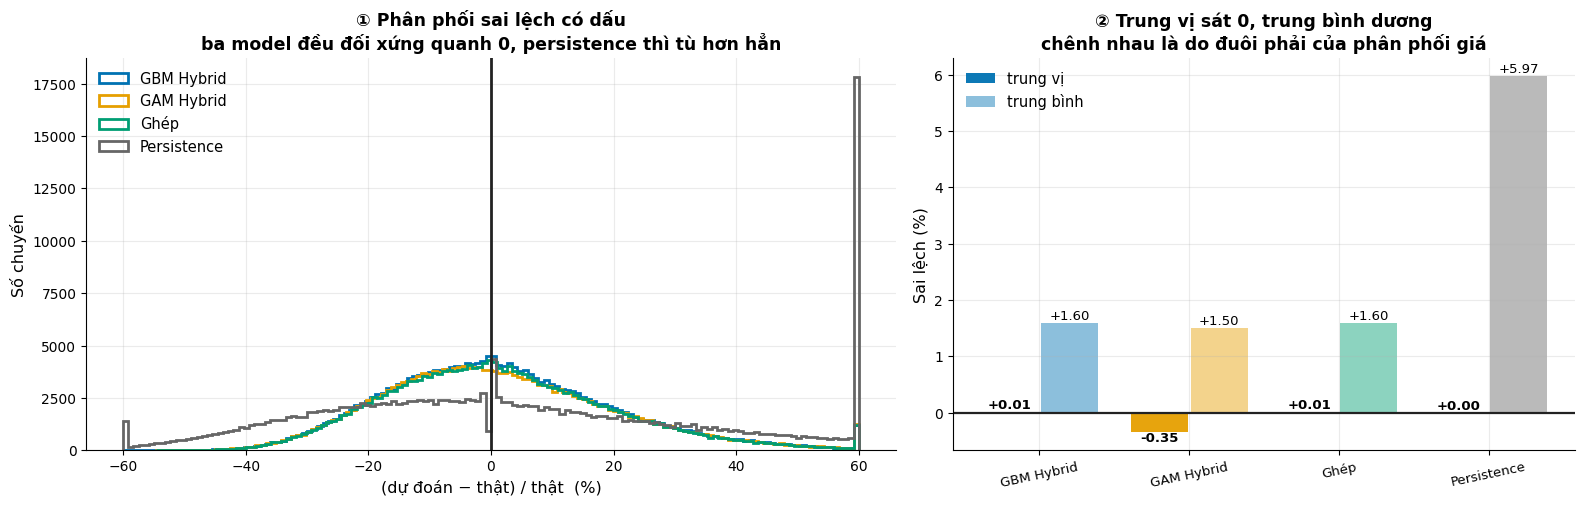

In [4]:
# ═════════ HINH XH1 — phan phoi sai lech co dau ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})

for m in MODEL:
    r = np.clip(D["r_" + m].values*100, -60, 60)
    ax[0].hist(r, bins=140, histtype="step", lw=2, color=MAU[m], label=m)
ax[0].axvline(0, color=INK, lw=2)
ax[0].set_xlabel("(dự đoán − thật) / thật  (%)"); ax[0].set_ylabel("Số chuyến")
ax[0].legend(frameon=False)
ax[0].set_title("① Phân phối sai lệch có dấu\nba model đều đối xứng quanh 0, persistence thì tù hơn hẳn",
                fontweight="bold")

x = np.arange(len(MODEL))
tv = [TONG.loc[m, "Trung vị"]*100 for m in MODEL]
tb = [TONG.loc[m, "Trung bình"]*100 for m in MODEL]
ax[1].bar(x - .2, tv, .38, color=[MAU[m] for m in MODEL], alpha=.95, label="trung vị")
ax[1].bar(x + .2, tb, .38, color=[MAU[m] for m in MODEL], alpha=.45, label="trung bình")
ax[1].axhline(0, color=INK, lw=1.6)
for i, m in enumerate(MODEL):
    ax[1].text(i - .2, tv[i] + (.06 if tv[i] >= 0 else -.16), f"{tv[i]:+.2f}",
               ha="center", fontsize=9.5, fontweight="bold")
    ax[1].text(i + .2, tb[i] + (.06 if tb[i] >= 0 else -.16), f"{tb[i]:+.2f}",
               ha="center", fontsize=9.5)
ax[1].set_xticks(x); ax[1].set_xticklabels(MODEL, rotation=12, fontsize=9.5)
ax[1].set_ylabel("Sai lệch (%)"); ax[1].legend(frameon=False)
ax[1].set_title("② Trung vị sát 0, trung bình dương\nchênh nhau là do đuôi phải của phân phối giá",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH1_phan_phoi_sai_lech.png"); plt.show()

## 2. Theo khoảng quãng đường — chỗ có chuyện

Đây là lát cắt quan trọng nhất, vì quãng đường **biết trước lúc dự báo** nên bất kỳ thiên lệch nào
theo chiều này đều sửa được ngay mà không cần train lại.

In [5]:
def bang_theo_km(cot_r):
    hang = []
    for g in TEN_KM:
        s = D[D.kmb.astype(str) == g]
        if len(s) < 20:
            continue
        h = {"Nhóm km": g, "n": len(s)}
        for m in MODEL:
            h[m] = np.median(s["r_" + m])
        hang.append(h)
    return pd.DataFrame(hang)

BK = bang_theo_km("trung vị")
d = BK.copy()
for m in MODEL:
    d[m] = (d[m]*100).round(2).astype(str) + "%"
print("TRUNG VỊ SAI LỆCH THEO NHÓM QUÃNG ĐƯỜNG (âm = đoán THẤP hơn thật)")
print(d.to_string(index=False))

print("\nGiá thật trung bình so với giá model đoán, nhóm đuôi:")
for g in ["15–18", "18–20", "20–25", ">25"]:
    s = D[D.kmb.astype(str) == g]
    print(f"  {g:>6s} n={len(s):>4,} | thật {s.y.mean():>9,.0f}đ · "
          f"GBM {s['GBM Hybrid'].mean():>9,.0f}đ ({s['GBM Hybrid'].mean()/s.y.mean()-1:+.1%}) · "
          f"GAM {s['GAM Hybrid'].mean():>9,.0f}đ ({s['GAM Hybrid'].mean()/s.y.mean()-1:+.1%})")

TRUNG VỊ SAI LỆCH THEO NHÓM QUÃNG ĐƯỜNG (âm = đoán THẤP hơn thật)
Nhóm km      n GBM Hybrid GAM Hybrid   Ghép Persistence
     <5  35158      0.54%     -0.66%  0.54%       4.35%
    5–8 125255     -0.11%     -0.28% -0.11%       1.54%
   8–12  52972     -0.22%     -0.28% -0.19%      -6.62%
  12–15   2045      0.54%      -0.1% -0.08%     -36.18%
  15–18    422      1.71%     -1.29% -0.55%     -50.97%
  18–20     99     -7.08%     -3.29% -4.06%     -55.73%
  20–25     97     -13.3%     -0.73% -4.04%     -63.55%
    >25     42    -25.08%      3.68% -1.76%     -74.64%

Giá thật trung bình so với giá model đoán, nhóm đuôi:
   15–18 n= 422 | thật   262,991đ · GBM   265,429đ (+0.9%) · GAM   257,131đ (-2.2%)
   18–20 n=  99 | thật   289,717đ · GBM   268,836đ (-7.2%) · GAM   280,345đ (-3.2%)
   20–25 n=  97 | thật   332,072đ · GBM   290,119đ (-12.6%) · GAM   332,494đ (+0.1%)
     >25 n=  42 | thật   463,286đ · GBM   328,995đ (-29.0%) · GAM   462,720đ (-0.1%)


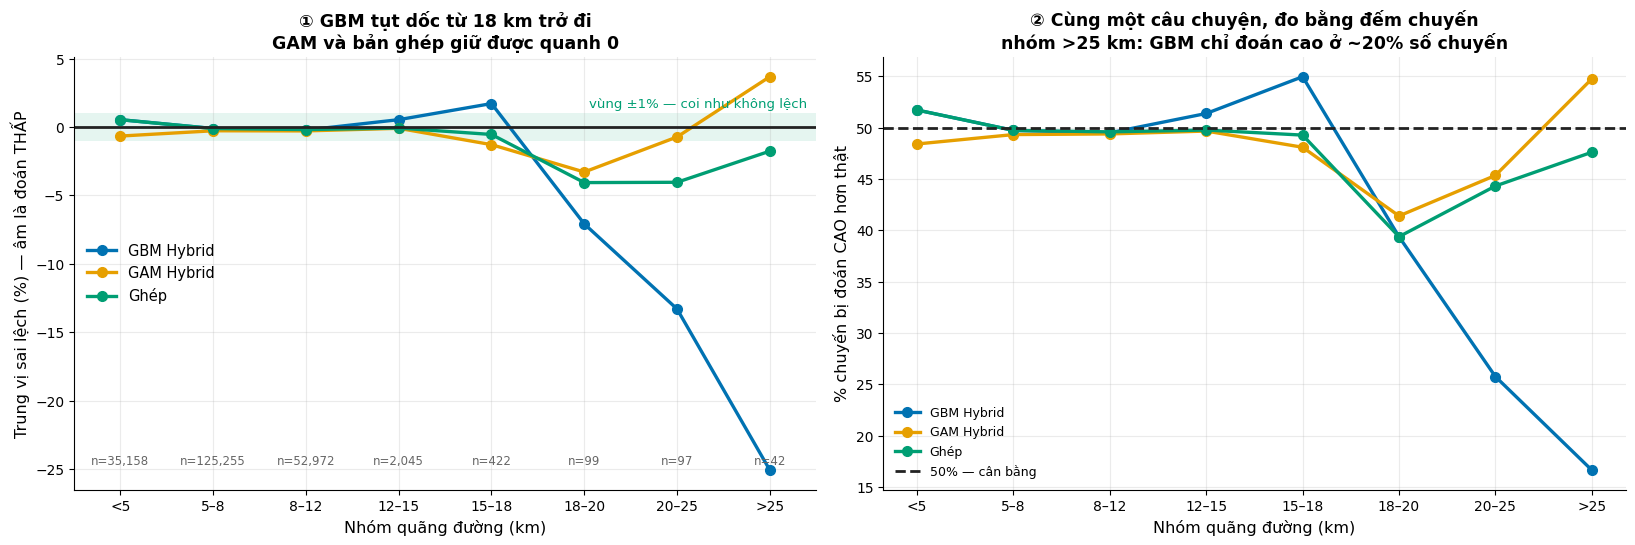

In [6]:
# ═════════ HINH XH2 — xu huong theo quang duong ═════════
fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.6))
x = np.arange(len(BK))

# Persistence lệch tới −75% ở nhóm xa nên để chung sẽ nén hết ba đường model.
# Nó có mặt ở hình XH1 và XH5, chỗ nó nói được điều gì đó.
VE = ["GBM Hybrid", "GAM Hybrid", "Ghép"]
for m in VE:
    ax[0].plot(x, BK[m]*100, "o-", color=MAU[m], lw=2.4, ms=7, label=m)
ax[0].axhline(0, color=INK, lw=2)
ax[0].fill_between([-.5, len(BK)-.5], -1, 1, color=GREEN, alpha=.10, lw=0)
ax[0].text(len(BK)-.6, 1.4, "vùng ±1% — coi như không lệch", fontsize=9.5,
           color=GREEN, ha="right")
ax[0].set_xticks(x); ax[0].set_xticklabels(BK["Nhóm km"])
ax[0].set_xlim(-.5, len(BK)-.5)
ax[0].set_xlabel("Nhóm quãng đường (km)")
ax[0].set_ylabel("Trung vị sai lệch (%) — âm là đoán THẤP")
ax[0].legend(frameon=False)
ax[0].set_title("① GBM tụt dốc từ 18 km trở đi\nGAM và bản ghép giữ được quanh 0",
                fontweight="bold")
y_dat = ax[0].get_ylim()[0]
for i in x:
    ax[0].annotate(f"n={BK.n.iloc[i]:,}", (i, y_dat*.93), ha="center",
                   fontsize=8.5, color=MUT)

# ② tỷ lệ đoán cao theo nhóm
for m in VE:
    v = [(D[D.kmb.astype(str) == g]["r_" + m] > 0).mean()*100 for g in BK["Nhóm km"]]
    ax[1].plot(x, v, "o-", color=MAU[m], lw=2.4, ms=7, label=m)
ax[1].axhline(50, color=INK, lw=2, ls="--", label="50% — cân bằng")
ax[1].set_xticks(x); ax[1].set_xticklabels(BK["Nhóm km"])
ax[1].set_xlabel("Nhóm quãng đường (km)")
ax[1].set_ylabel("% chuyến bị đoán CAO hơn thật")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_title("② Cùng một câu chuyện, đo bằng đếm chuyến\nnhóm >25 km: GBM chỉ đoán cao ở ~20% số chuyến",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH2_xu_huong_theo_km.png"); plt.show()

### Vì sao GBM tụt ở đuôi

Cây quyết định không ngoại suy được: qua nhát cắt cuối cùng, dự đoán trở thành hằng số. Vùng quãng
đường xa lại cực thưa trong tập train, nên gần như không có nhát cắt nào ở đó.

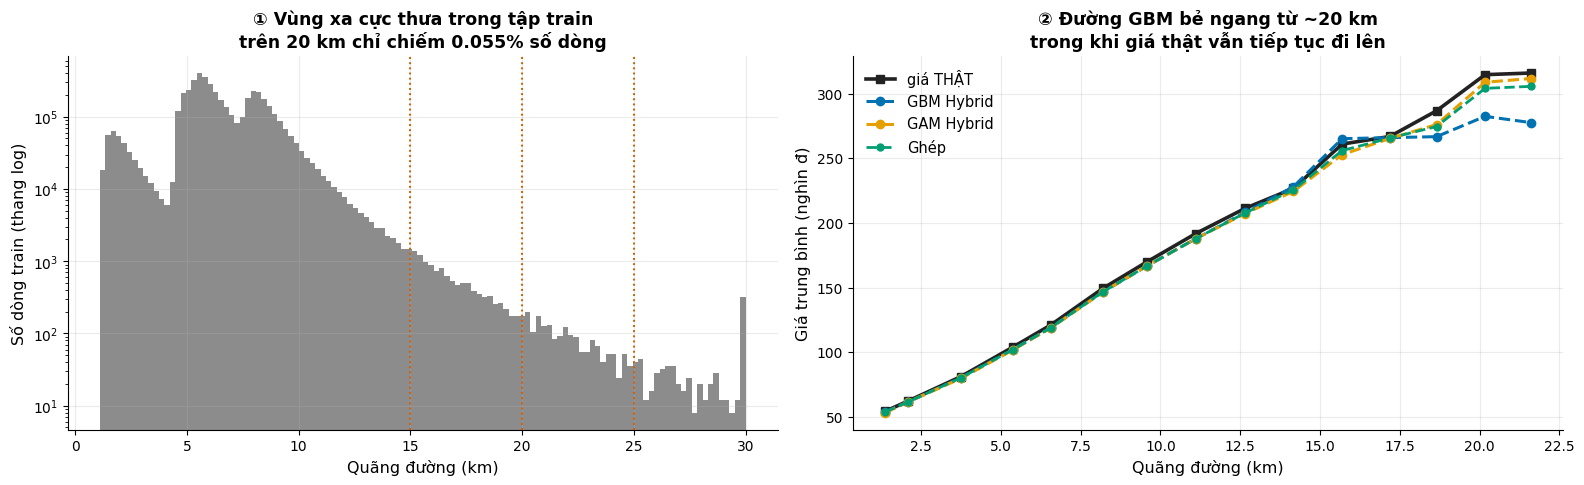

Nhóm >20 km (139 chuyến): giá thật TB 371,719đ
  GBM Hybrid   đoán TB   301,866đ  (-18.8%)
  GAM Hybrid   đoán TB   371,843đ  (+0.0%)
  Ghép         đoán TB   359,073đ  (-3.4%)
  Persistence  đoán TB   126,252đ  (-66.0%)


In [7]:
# ═════════ HINH XH3 — vi sao GBM tut o duoi ═════════
tr = pd.read_parquet("../data/hcm_train_ready.parquet", columns=["split", "quote_distance"])
tr = tr[tr.split == "train"]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].hist(np.clip(tr.quote_distance, 0, 30), bins=120, color=MUT, alpha=.75)
ax[0].set_yscale("log")
for v in (15, 20, 25):
    ax[0].axvline(v, color=RED, lw=1.4, ls=":")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Số dòng train (thang log)")
ax[0].set_title("① Vùng xa cực thưa trong tập train\n"
                f"trên 20 km chỉ chiếm {(tr.quote_distance > 20).mean():.3%} số dòng",
                fontweight="bold")

# ② giá thật vs giá đoán theo quãng đường
b = D.copy()
b["bin"] = pd.cut(b.km, np.arange(0, 32, 1.5))
g = b.groupby("bin", observed=True).agg(n=("y", "size"), km=("km", "mean"), that=("y", "mean"),
                                        gbm=("GBM Hybrid", "mean"), gam=("GAM Hybrid", "mean"),
                                        ghep=("Ghép", "mean"))
g = g[g.n >= 25]
ax[1].plot(g.km, g.that/1000, "s-", color=INK, lw=2.6, ms=6, label="giá THẬT")
ax[1].plot(g.km, g.gbm/1000, "o--", color=BLUE, lw=2.2, ms=6, label="GBM Hybrid")
ax[1].plot(g.km, g.gam/1000, "o--", color=ORANGE, lw=2.2, ms=6, label="GAM Hybrid")
ax[1].plot(g.km, g.ghep/1000, "o--", color=GREEN, lw=2, ms=5, label="Ghép")
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Giá trung bình (nghìn đ)")
ax[1].legend(frameon=False)
ax[1].set_title("② Đường GBM bẻ ngang từ ~20 km\ntrong khi giá thật vẫn tiếp tục đi lên",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH3_vi_sao_tut_o_duoi.png"); plt.show()

xa = D[D.km > 20]
print(f"Nhóm >20 km ({len(xa):,} chuyến): giá thật TB {xa.y.mean():,.0f}đ")
for m in MODEL:
    print(f"  {m:12s} đoán TB {xa[m].mean():>9,.0f}đ  ({xa[m].mean()/xa.y.mean()-1:+.1%})")

## 3. Chi tiết từng nhánh — lỗi nằm ở tầng nào

Model là hai tầng nhân nhau, nên phải tách xem thiên lệch đến từ nhánh giá cơ bản hay nhánh hệ số
nhân.

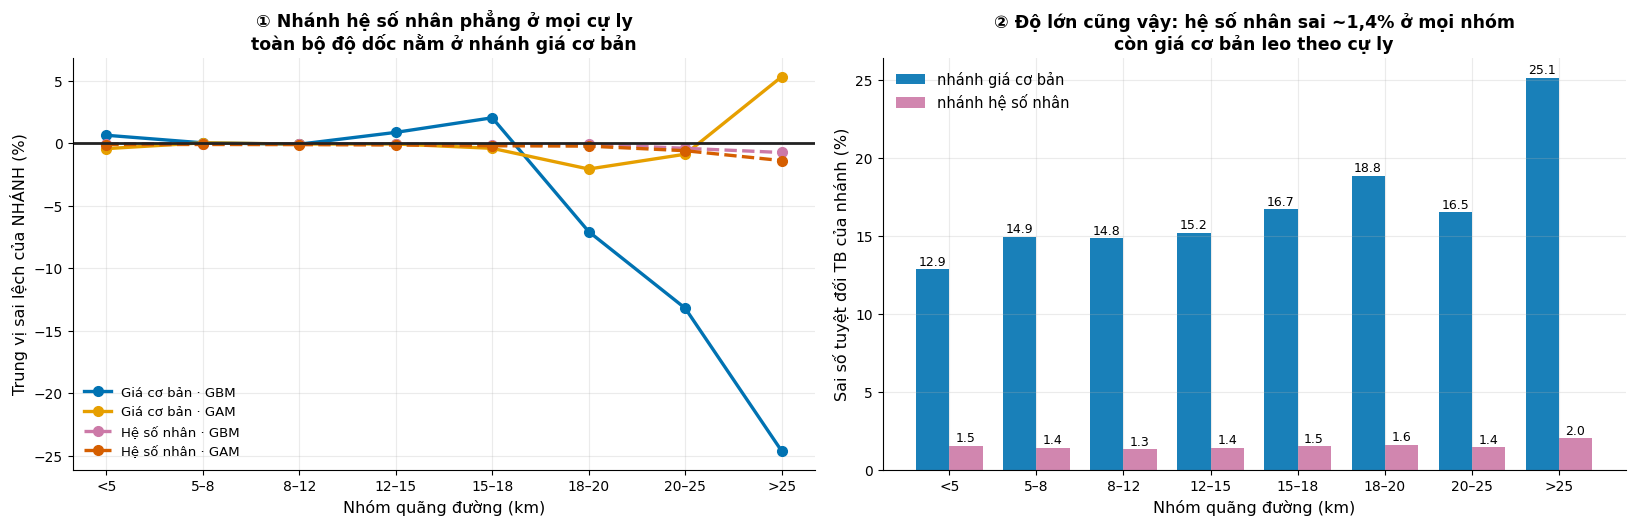

Nhóm >20 km — sai số từng nhánh (GBM):
  giá cơ bản : trung vị -14.82% · |sai số| TB 19.10%
  hệ số nhân : trung vị -0.53% · |sai số| TB 1.61%


In [8]:
# ═════════ HINH XH4 — hai nhanh ═════════
NH = {"Giá cơ bản · GBM": (D.b_GBM, D.b_that, BLUE),
      "Giá cơ bản · GAM": (D.b_GAM, D.b_that, ORANGE),
      "Hệ số nhân · GBM": (D.h_GBM, D.h_that, PURPLE),
      "Hệ số nhân · GAM": (D.h_GAM, D.h_that, RED)}
for ten, (p, t, _) in NH.items():
    D["rr_" + ten] = (p - t) / t

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.4))
x = np.arange(len(TEN_KM))
for ten, (_, _, mau) in NH.items():
    v = []
    for g in TEN_KM:
        s = D[D.kmb.astype(str) == g]
        v.append(np.median(s["rr_" + ten])*100 if len(s) >= 20 else np.nan)
    ls = "-" if "Giá cơ bản" in ten else "--"
    ax[0].plot(x, v, "o" + ls, color=mau, lw=2.4, ms=7, label=ten)
ax[0].axhline(0, color=INK, lw=2)
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN_KM)
ax[0].set_xlabel("Nhóm quãng đường (km)")
ax[0].set_ylabel("Trung vị sai lệch của NHÁNH (%)")
ax[0].legend(frameon=False, fontsize=9.5)
ax[0].set_title("① Nhánh hệ số nhân phẳng ở mọi cự ly\ntoàn bộ độ dốc nằm ở nhánh giá cơ bản",
                fontweight="bold")

# ② độ lớn sai số hai nhánh
v_cb = [np.mean(np.abs(D[D.kmb.astype(str) == g]["rr_Giá cơ bản · GBM"]))*100 for g in TEN_KM]
v_hs = [np.mean(np.abs(D[D.kmb.astype(str) == g]["rr_Hệ số nhân · GBM"]))*100 for g in TEN_KM]
ax[1].bar(x - .19, v_cb, .38, color=BLUE, alpha=.9, label="nhánh giá cơ bản")
ax[1].bar(x + .19, v_hs, .38, color=PURPLE, alpha=.9, label="nhánh hệ số nhân")
for i in x:
    ax[1].text(i - .19, v_cb[i] + .25, f"{v_cb[i]:.1f}", ha="center", fontsize=9)
    ax[1].text(i + .19, v_hs[i] + .25, f"{v_hs[i]:.1f}", ha="center", fontsize=9)
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN_KM)
ax[1].set_xlabel("Nhóm quãng đường (km)"); ax[1].set_ylabel("Sai số tuyệt đối TB của nhánh (%)")
ax[1].legend(frameon=False)
ax[1].set_title("② Độ lớn cũng vậy: hệ số nhân sai ~1,4% ở mọi nhóm\ncòn giá cơ bản leo theo cự ly",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH4_hai_nhanh.png"); plt.show()

print("Nhóm >20 km — sai số từng nhánh (GBM):")
xa = D[D.km > 20]
print(f"  giá cơ bản : trung vị {np.median(xa['rr_Giá cơ bản · GBM']):+.2%} · "
      f"|sai số| TB {np.mean(np.abs(xa['rr_Giá cơ bản · GBM'])):.2%}")
print(f"  hệ số nhân : trung vị {np.median(xa['rr_Hệ số nhân · GBM']):+.2%} · "
      f"|sai số| TB {np.mean(np.abs(xa['rr_Hệ số nhân · GBM'])):.2%}")

## 4. Xu hướng theo biến động thị trường

Model chỉ được nhìn giá đối thủ **trễ 5 phút**. Câu hỏi: khi giá vừa nhảy, model có đuổi kịp không,
hay nó bám lại mức cũ?

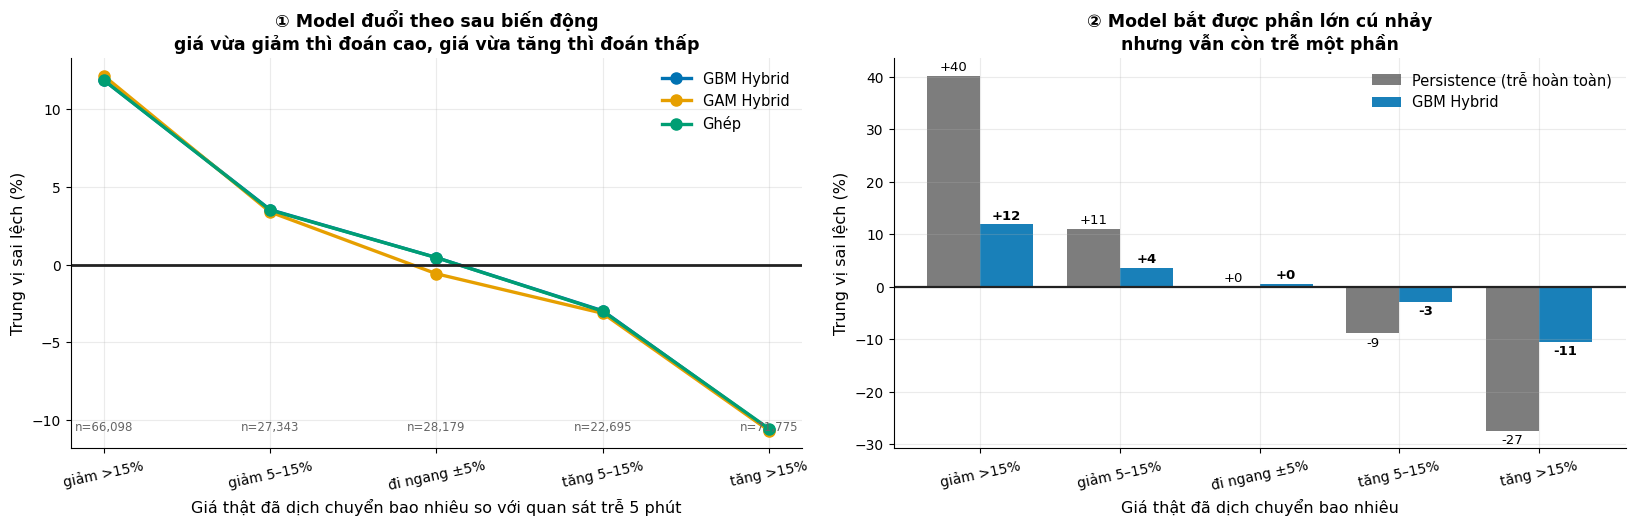

Tương quan giữa mức dịch chuyển giá và sai lệch có dấu:
  GBM Hybrid   -0.492
  GAM Hybrid   -0.492
  Ghép         -0.490
  Persistence  -0.847

(âm mạnh = model càng bám giá cũ, càng không đuổi kịp biến động)


In [9]:
# ═════════ HINH XH5 — model tre so voi bien dong ═════════
D["dong"] = (D.y - D.pers) / D.pers          # giá đã dịch chuyển bao nhiêu kể từ lần quan sát
NHOM_DONG = pd.cut(D.dong, [-1, -.15, -.05, .05, .15, 10],
                   labels=["giảm >15%", "giảm 5–15%", "đi ngang ±5%", "tăng 5–15%", "tăng >15%"])
D["dongb"] = NHOM_DONG

fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.4))
x = np.arange(5)
for m in ["GBM Hybrid", "GAM Hybrid", "Ghép"]:
    v = [np.median(D[D.dongb == g]["r_" + m])*100 for g in NHOM_DONG.cat.categories]
    ax[0].plot(x, v, "o-", color=MAU[m], lw=2.4, ms=8, label=m)
ax[0].axhline(0, color=INK, lw=2)
ax[0].set_xticks(x); ax[0].set_xticklabels(NHOM_DONG.cat.categories, rotation=12)
ax[0].set_xlabel("Giá thật đã dịch chuyển bao nhiêu so với quan sát trễ 5 phút")
ax[0].set_ylabel("Trung vị sai lệch (%)")
ax[0].legend(frameon=False)
ax[0].set_title("① Model đuổi theo sau biến động\ngiá vừa giảm thì đoán cao, giá vừa tăng thì đoán thấp",
                fontweight="bold")
for i, g in enumerate(NHOM_DONG.cat.categories):
    ax[0].annotate(f"n={(D.dongb == g).sum():,}", (i, ax[0].get_ylim()[0]*.9),
                   ha="center", fontsize=8.5, color=MUT)

# ② so với persistence — model có đỡ trễ hơn không
v_m = [np.median(D[D.dongb == g]["r_GBM Hybrid"])*100 for g in NHOM_DONG.cat.categories]
v_p = [np.median(D[D.dongb == g]["r_Persistence"])*100 for g in NHOM_DONG.cat.categories]
ax[1].bar(x - .19, v_p, .38, color=MUT, alpha=.85, label="Persistence (trễ hoàn toàn)")
ax[1].bar(x + .19, v_m, .38, color=BLUE, alpha=.9, label="GBM Hybrid")
ax[1].axhline(0, color=INK, lw=1.6)
for i in x:
    ax[1].text(i - .19, v_p[i] + (1 if v_p[i] >= 0 else -2.4), f"{v_p[i]:+.0f}",
               ha="center", fontsize=9.5)
    ax[1].text(i + .19, v_m[i] + (1 if v_m[i] >= 0 else -2.4), f"{v_m[i]:+.0f}",
               ha="center", fontsize=9.5, fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(NHOM_DONG.cat.categories, rotation=12)
ax[1].set_xlabel("Giá thật đã dịch chuyển bao nhiêu")
ax[1].set_ylabel("Trung vị sai lệch (%)"); ax[1].legend(frameon=False)
ax[1].set_title("② Model bắt được phần lớn cú nhảy\nnhưng vẫn còn trễ một phần",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH5_theo_bien_dong.png"); plt.show()

print(f"Tương quan giữa mức dịch chuyển giá và sai lệch có dấu:")
for m in MODEL:
    print(f"  {m:12s} {np.corrcoef(D.dong, D['r_' + m])[0, 1]:+.3f}")
print("\n(âm mạnh = model càng bám giá cũ, càng không đuổi kịp biến động)")

## 5. Hiệu chuẩn — model báo X thì thực tế bao nhiêu

Đây là câu hỏi dùng được lúc vận hành, vì lúc đó chỉ biết giá model báo chứ chưa biết giá thật.

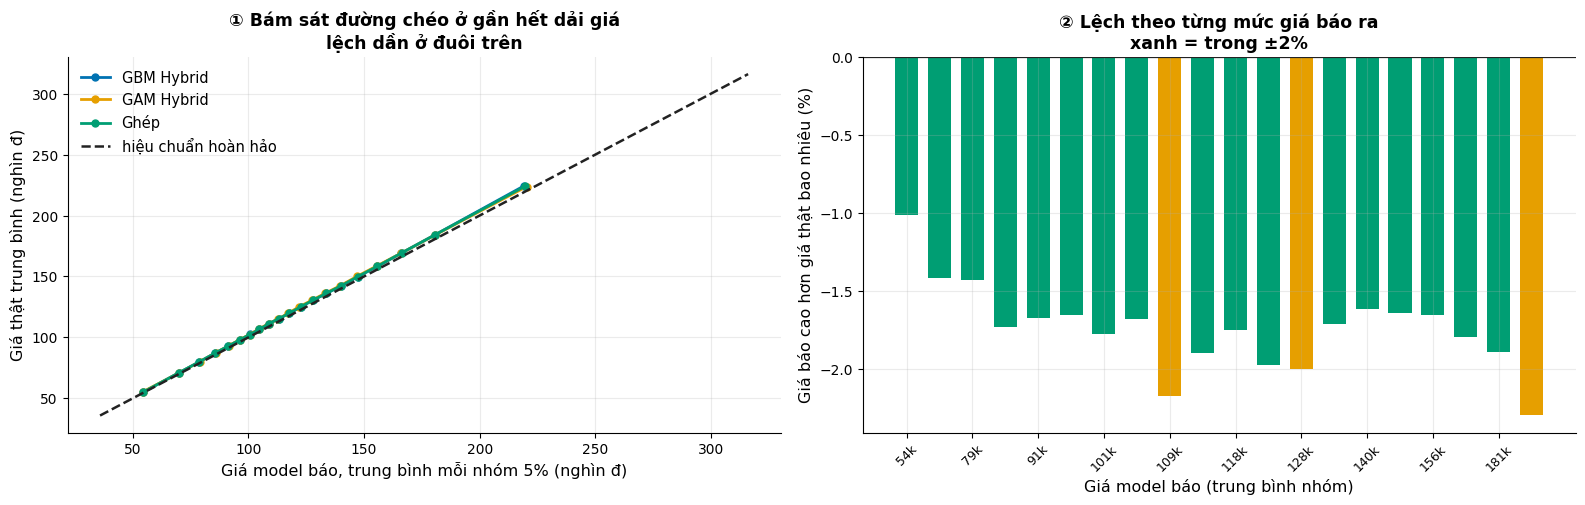

Model báo X thì giá thật trung bình là bao nhiêu (GBM Hybrid):
  báo ~    54k (n=10,805) → thật ~    55k  (-1.02%)
  báo ~    91k (n=10,805) → thật ~    93k  (-1.68%)
  báo ~   113k (n=10,804) → thật ~   115k  (-1.90%)
  báo ~   140k (n=10,804) → thật ~   143k  (-1.62%)
  báo ~   181k (n=10,804) → thật ~   184k  (-1.89%)
  báo ~   219k (n=10,805) → thật ~   224k  (-2.30%)


In [10]:
# ═════════ HINH XH6 — hieu chuan ═════════
fig, ax = plt.subplots(1, 2, figsize=(16, 5.2))

for m in ["GBM Hybrid", "GAM Hybrid", "Ghép"]:
    q = pd.qcut(D[m], 20, duplicates="drop")
    g = D.groupby(q, observed=True).agg(p=(m, "mean"), y=("y", "mean"))
    ax[0].plot(g.p/1000, g.y/1000, "o-", color=MAU[m], lw=2, ms=5, label=m)
lim = [D["GBM Hybrid"].quantile(.001)/1000, D["GBM Hybrid"].quantile(.999)/1000]
ax[0].plot(lim, lim, color=INK, lw=1.8, ls="--", label="hiệu chuẩn hoàn hảo")
ax[0].set_xlabel("Giá model báo, trung bình mỗi nhóm 5% (nghìn đ)")
ax[0].set_ylabel("Giá thật trung bình (nghìn đ)")
ax[0].legend(frameon=False)
ax[0].set_title("① Bám sát đường chéo ở gần hết dải giá\nlệch dần ở đuôi trên", fontweight="bold")

q = pd.qcut(D["GBM Hybrid"], 20, duplicates="drop")
g = D.groupby(q, observed=True).agg(p=("GBM Hybrid", "mean"), y=("y", "mean"), n=("y", "size"))
g["lech"] = (g.p/g.y - 1)*100
ax[1].bar(range(len(g)), g.lech, .7,
          color=[GREEN if abs(v) < 2 else (ORANGE if abs(v) < 5 else RED) for v in g.lech])
ax[1].axhline(0, color=INK, lw=1.6)
ax[1].set_xticks(range(0, len(g), 2))
ax[1].set_xticklabels([f"{v/1000:.0f}k" for v in g.p.values[::2]], rotation=45, fontsize=9)
ax[1].set_xlabel("Giá model báo (trung bình nhóm)")
ax[1].set_ylabel("Giá báo cao hơn giá thật bao nhiêu (%)")
ax[1].set_title("② Lệch theo từng mức giá báo ra\nxanh = trong ±2%", fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH6_hieu_chuan.png"); plt.show()

print("Model báo X thì giá thật trung bình là bao nhiêu (GBM Hybrid):")
for i in [0, 4, 9, 14, 18, 19]:
    r = g.iloc[i]
    print(f"  báo ~{r.p/1000:>6.0f}k (n={r.n:>6,.0f}) → thật ~{r.y/1000:>6.0f}k  ({r.lech:+.2f}%)")

## 6. Bảng tình huống — vẽ riêng cho từng model

Gom hai chiều đã phân tích thành một hình: cột là model, hàng trên là quãng đường, hàng dưới là mức
biến động giá. Cột màu đỏ nghĩa là model đoán THẤP hơn giá thật, xanh là đoán CAO hơn, xám là nằm
trong ±1% nên coi như không lệch.

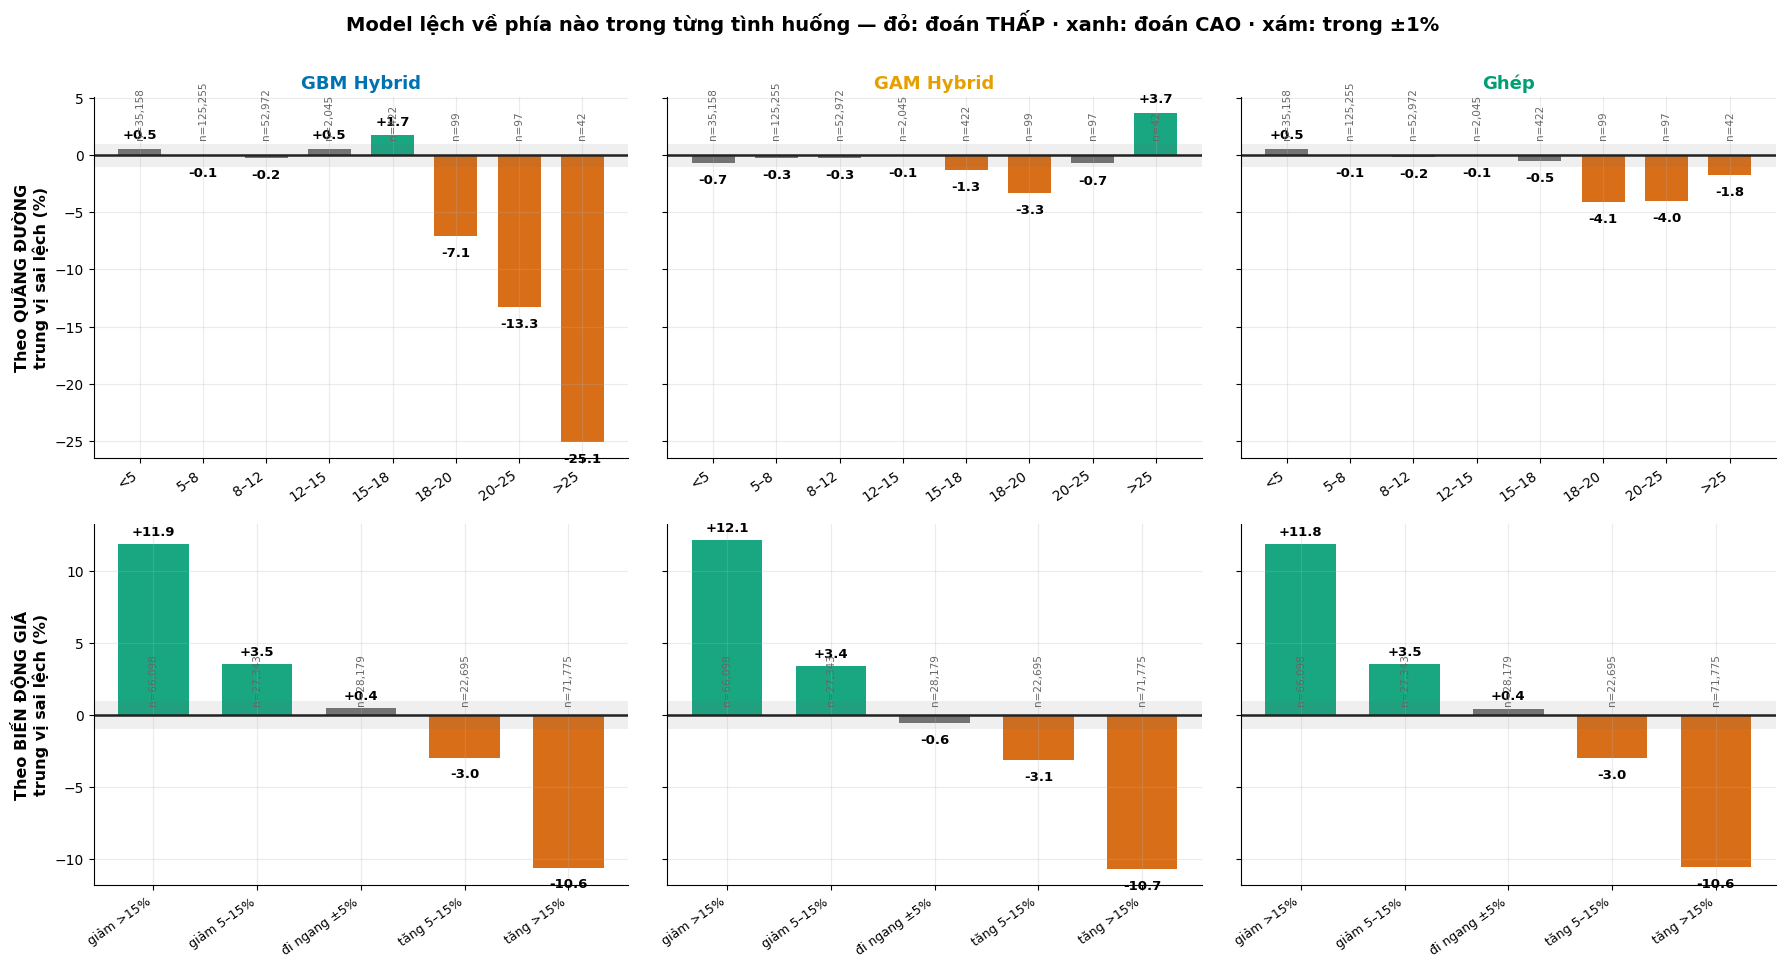

BẢNG TÌNH HUỐNG — trung vị sai lệch (%), âm là đoán THẤP


          Tình huống       n GBM Hybrid GAM Hybrid   Ghép
   quãng đường <5 km  35,158      +0.54      -0.66  +0.54
  quãng đường 5–8 km 125,255      -0.11      -0.28  -0.11
 quãng đường 8–12 km  52,972      -0.22      -0.28  -0.19
quãng đường 12–15 km   2,045      +0.54      -0.10  -0.08
quãng đường 15–18 km     422      +1.71      -1.29  -0.55
quãng đường 18–20 km      99      -7.08      -3.29  -4.06
quãng đường 20–25 km      97     -13.30      -0.73  -4.04
  quãng đường >25 km      42     -25.08      +3.68  -1.76
       giá giảm >15%  66,098     +11.85     +12.13 +11.85
      giá giảm 5–15%  27,343      +3.53      +3.38  +3.50
    giá đi ngang ±5%  28,179      +0.45      -0.59  +0.44
      giá tăng 5–15%  22,695      -2.97      -3.13  -3.00
       giá tăng >15%  71,775     -10.59     -10.67 -10.55


In [11]:
# ═════════ HINH XH7 — tung model, hai chieu tinh huong ═════════
VE = ["GBM Hybrid", "GAM Hybrid", "Ghép"]
DONG_CAT = list(D.dongb.cat.categories)

def mau_cot(v):
    if v < -1:  return RED
    if v > 1:   return GREEN
    return MUT

fig, ax = plt.subplots(2, len(VE), figsize=(6.0*len(VE), 9.6), sharey="row")

for j, m in enumerate(VE):
    # ── hàng trên: theo quãng đường ──
    a = ax[0, j]
    v = [np.median(D[D.kmb.astype(str) == g]["r_" + m])*100 for g in TEN_KM]
    n = [(D.kmb.astype(str) == g).sum() for g in TEN_KM]
    a.bar(range(len(TEN_KM)), v, .68, color=[mau_cot(x) for x in v], alpha=.9)
    a.axhline(0, color=INK, lw=1.8)
    a.axhspan(-1, 1, color=MUT, alpha=.10, lw=0)
    for i, (val, nn) in enumerate(zip(v, n)):
        a.text(i, val + (.9 if val >= 0 else -1.8), f"{val:+.1f}", ha="center",
               fontsize=9.5, fontweight="bold")
        a.text(i, 1.5, f"n={nn:,}", ha="center", fontsize=7.5, color=MUT, rotation=90)
    a.set_xticks(range(len(TEN_KM))); a.set_xticklabels(TEN_KM, rotation=35, ha="right")
    a.set_title(m, fontweight="bold", color=MAU[m], fontsize=13)
    if j == 0:
        a.set_ylabel("Theo QUÃNG ĐƯỜNG\ntrung vị sai lệch (%)", fontweight="bold")

    # ── hàng dưới: theo mức biến động giá ──
    a = ax[1, j]
    v2 = [np.median(D[D.dongb == g]["r_" + m])*100 for g in DONG_CAT]
    n2 = [(D.dongb == g).sum() for g in DONG_CAT]
    a.bar(range(len(DONG_CAT)), v2, .68, color=[mau_cot(x) for x in v2], alpha=.9)
    a.axhline(0, color=INK, lw=1.8)
    a.axhspan(-1, 1, color=MUT, alpha=.10, lw=0)
    for i, (val, nn) in enumerate(zip(v2, n2)):
        a.text(i, val + (.6 if val >= 0 else -1.4), f"{val:+.1f}", ha="center",
               fontsize=9.5, fontweight="bold")
        a.text(i, .8, f"n={nn:,}", ha="center", fontsize=7.5, color=MUT, rotation=90)
    a.set_xticks(range(len(DONG_CAT)))
    a.set_xticklabels([str(g) for g in DONG_CAT], rotation=35, ha="right", fontsize=9)
    if j == 0:
        a.set_ylabel("Theo BIẾN ĐỘNG GIÁ\ntrung vị sai lệch (%)", fontweight="bold")

fig.suptitle("Model lệch về phía nào trong từng tình huống — đỏ: đoán THẤP · "
             "xanh: đoán CAO · xám: trong ±1%",
             fontweight="bold", fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(HINH/"XH7_tung_model_theo_tinh_huong.png", bbox_inches="tight"); plt.show()

print("BẢNG TÌNH HUỐNG — trung vị sai lệch (%), âm là đoán THẤP")
hang = []
for g in TEN_KM:
    s_ = D[D.kmb.astype(str) == g]
    hang.append({"Tình huống": f"quãng đường {g} km", "n": len(s_),
                 **{m: np.median(s_["r_" + m])*100 for m in VE}})
for g in DONG_CAT:
    s_ = D[D.dongb == g]
    hang.append({"Tình huống": f"giá {g}", "n": len(s_),
                 **{m: np.median(s_["r_" + m])*100 for m in VE}})
B7 = pd.DataFrame(hang)
print(B7.to_string(index=False, formatters={**{m: "{:+.2f}".format for m in VE},
                                            "n": "{:,}".format}))
B7.to_csv(KQ/"XH_bang_tinh_huong.csv", index=False)

## 7. Bảng thống kê theo quãng đường

Bảng đầy đủ cho ba model: bao nhiêu chuyến, lệch bao nhiêu phần trăm, bao nhiêu phần trăm số chuyến
bị báo thấp, và quy ra tiền thì chênh bao nhiêu đồng mỗi chuyến.

In [12]:
# ══ Bảng thống kê đầy đủ theo nhóm quãng đường ═════════════════════════
VE = ["GBM Hybrid", "GAM Hybrid", "Ghép"]
hang = []
for g in TEN_KM:
    s_ = D[D.kmb.astype(str) == g]
    if len(s_) < 20:
        continue
    for m in VE:
        r = s_["r_" + m].values
        hang.append({
            "Nhóm km": g, "Model": m, "Số chuyến": len(s_),
            "Trung vị lệch %": np.median(r)*100,
            "Trung bình lệch %": r.mean()*100,
            "% chuyến bị báo THẤP": (r < 0).mean()*100,
            "Giá thật TB": s_.y.mean(),
            "Giá model báo TB": s_[m].mean(),
            "Chênh tiền TB": s_[m].mean() - s_.y.mean(),
            "MAPE %": np.abs(r).mean()*100,
        })
BTK = pd.DataFrame(hang)

d = BTK.copy()
for c in ["Trung vị lệch %", "Trung bình lệch %", "MAPE %"]:
    d[c] = d[c].round(2)
d["% chuyến bị báo THẤP"] = d["% chuyến bị báo THẤP"].round(1)
for c in ["Giá thật TB", "Giá model báo TB", "Chênh tiền TB"]:
    d[c] = d[c].round(0).astype(int).map("{:,}".format)
d["Số chuyến"] = d["Số chuyến"].map("{:,}".format)
print("BẢNG THỐNG KÊ THEO QUÃNG ĐƯỜNG")
print(d.to_string(index=False))
BTK.to_csv(KQ/"XH_thong_ke_theo_km.csv", index=False)

BẢNG THỐNG KÊ THEO QUÃNG ĐƯỜNG
Nhóm km      Model Số chuyến  Trung vị lệch %  Trung bình lệch %  % chuyến bị báo THẤP Giá thật TB Giá model báo TB Chênh tiền TB  MAPE %
     <5 GBM Hybrid    35,158             0.54               1.38                  48.3      79,456           78,292        -1,164   12.98
     <5 GAM Hybrid    35,158            -0.66               1.40                  51.6      79,456           78,084        -1,372   14.17
     <5       Ghép    35,158             0.54               1.38                  48.3      79,456           78,292        -1,164   12.98
    5–8 GBM Hybrid   125,255            -0.11               1.68                  50.3     116,561          114,490        -2,071   14.99
    5–8 GAM Hybrid   125,255            -0.28               1.52                  50.7     116,561          114,243        -2,319   15.05
    5–8       Ghép   125,255            -0.11               1.68                  50.3     116,561          114,488        -2,073   14.99
   

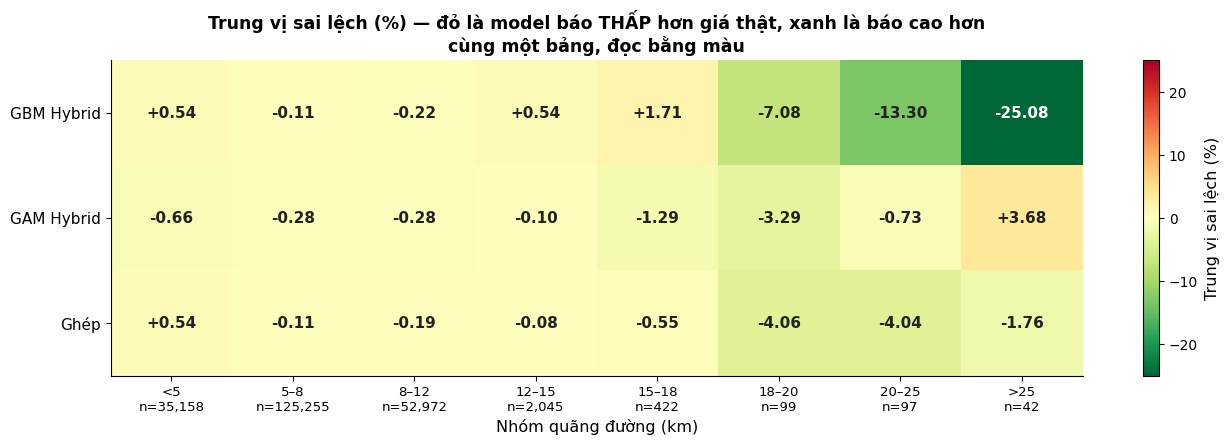

In [13]:
# ═════════ HINH XH8 — ban do nhiet trung vi lech ═════════
M = np.array([[np.median(D[D.kmb.astype(str) == g]["r_" + m])*100 for g in TEN_KM]
              for m in VE])
n_nhom = [(D.kmb.astype(str) == g).sum() for g in TEN_KM]

fig, ax = plt.subplots(figsize=(13.5, 4.6))
v = np.nanmax(np.abs(M))
im = ax.imshow(M, cmap="RdYlGn_r", aspect="auto", vmin=-v, vmax=v)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f"{M[i, j]:+.2f}", ha="center", va="center", fontsize=11,
                fontweight="bold", color="white" if abs(M[i, j]) > v*.55 else INK)
ax.set_xticks(range(len(TEN_KM)))
ax.set_xticklabels([f"{g}\nn={n:,}" for g, n in zip(TEN_KM, n_nhom)], fontsize=9.5)
ax.set_yticks(range(len(VE))); ax.set_yticklabels(VE, fontsize=11)
ax.set_xlabel("Nhóm quãng đường (km)")
ax.grid(False)
ax.set_title("Trung vị sai lệch (%) — đỏ là model báo THẤP hơn giá thật, xanh là báo cao hơn\n"
             "cùng một bảng, đọc bằng màu", fontweight="bold")
plt.colorbar(im, ax=ax, label="Trung vị sai lệch (%)")
plt.tight_layout(); plt.savefig(HINH/"XH8_ban_do_nhiet_lech.png"); plt.show()

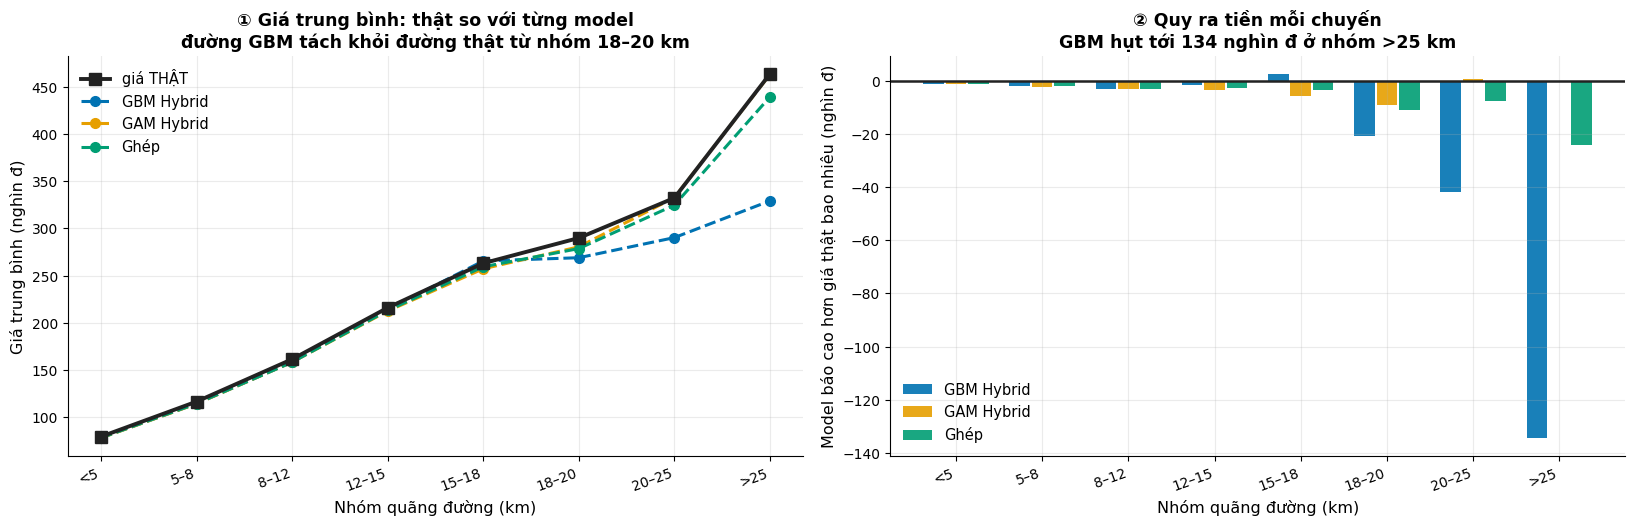

Chênh tiền trung bình mỗi chuyến (model báo − giá thật):
   15–18 n=  422 | thật   262,991đ | GBM Hybrid    +2,438đ · GAM Hybrid    -5,860đ · Ghép    -3,714đ
   18–20 n=   99 | thật   289,717đ | GBM Hybrid   -20,881đ · GAM Hybrid    -9,373đ · Ghép   -11,208đ
   20–25 n=   97 | thật   332,072đ | GBM Hybrid   -41,953đ · GAM Hybrid      +422đ · Ghép    -7,623đ
     >25 n=   42 | thật   463,286đ | GBM Hybrid  -134,291đ · GAM Hybrid      -565đ · Ghép   -24,247đ


In [14]:
# ═════════ HINH XH9 — quy ra tien ═════════
g_that = [D[D.kmb.astype(str) == g].y.mean()/1000 for g in TEN_KM]
fig, ax = plt.subplots(1, 2, figsize=(16.5, 5.4))
x = np.arange(len(TEN_KM))

ax[0].plot(x, g_that, "s-", color=INK, lw=2.8, ms=8, label="giá THẬT", zorder=5)
for m in VE:
    v = [D[D.kmb.astype(str) == g][m].mean()/1000 for g in TEN_KM]
    ax[0].plot(x, v, "o--", color=MAU[m], lw=2.2, ms=7, label=m)
ax[0].set_xticks(x); ax[0].set_xticklabels(TEN_KM, rotation=20, ha="right")
ax[0].set_xlabel("Nhóm quãng đường (km)"); ax[0].set_ylabel("Giá trung bình (nghìn đ)")
ax[0].legend(frameon=False)
ax[0].set_title("① Giá trung bình: thật so với từng model\n"
                "đường GBM tách khỏi đường thật từ nhóm 18–20 km", fontweight="bold")

w = .26
for k, m in enumerate(VE):
    v = [(D[D.kmb.astype(str) == g][m].mean() - D[D.kmb.astype(str) == g].y.mean())/1000
         for g in TEN_KM]
    ax[1].bar(x + (k-1)*w, v, w*.92, color=MAU[m], alpha=.9, label=m)
ax[1].axhline(0, color=INK, lw=1.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(TEN_KM, rotation=20, ha="right")
ax[1].set_xlabel("Nhóm quãng đường (km)")
ax[1].set_ylabel("Model báo cao hơn giá thật bao nhiêu (nghìn đ)")
ax[1].legend(frameon=False)
ax[1].set_title("② Quy ra tiền mỗi chuyến\nGBM hụt tới 134 nghìn đ ở nhóm >25 km",
                fontweight="bold")

plt.tight_layout(); plt.savefig(HINH/"XH9_quy_ra_tien.png"); plt.show()

print("Chênh tiền trung bình mỗi chuyến (model báo − giá thật):")
for g in TEN_KM[-4:]:
    s_ = D[D.kmb.astype(str) == g]
    print(f"  {g:>6s} n={len(s_):>5,} | thật {s_.y.mean():>9,.0f}đ | " +
          " · ".join(f"{m} {s_[m].mean()-s_.y.mean():>+9,.0f}đ" for m in VE))

## 8. Kết luận

**Tổng thể model không thiên lệch.** Trung vị sai lệch +0,01%, tỷ lệ đoán cao đúng 50,0%. Không cần
và không nên hiệu chỉnh bằng cách cộng trừ một hằng số.

**Nhưng có hai xu hướng rõ, và cả hai đều nhận ra được trước khi dự báo:**

1. **Chuyến càng dài, GBM càng đoán thấp.** Từ 18 km trở đi trung vị bắt đầu âm, tới nhóm trên 25 km
   thì giá thật trung bình 463k mà model báo 329k. Nguyên nhân là cây không ngoại suy được và vùng
   đó chỉ chiếm 0,06% tập train. GAM không bị, nên bản ghép sửa được chỗ này.
2. **Model đuổi theo sau biến động.** Giá vừa giảm mạnh thì model đoán cao, giá vừa tăng mạnh thì
   đoán thấp — tương quan −0,49. Đây là hệ quả của việc chỉ được nhìn giá trễ 5 phút, và nó có nghĩa
   là đúng lúc thị trường tăng nóng thì model báo thấp hơn thực tế.

**Nhánh hệ số nhân không phải thủ phạm.** Nó sai đều khoảng 1,4% ở mọi cự ly, trung vị phẳng. Toàn
bộ độ dốc theo quãng đường nằm ở nhánh giá cơ bản.

**Ý nghĩa vận hành.** Nếu đội pricing dùng model này, hai chỗ cần cảnh báo là chuyến đường dài và
thời điểm thị trường vừa tăng giá — cả hai đều là lúc model báo thấp hơn giá đối thủ thật, tức có
nguy cơ để giá thấp hơn mức lẽ ra bán được.

In [15]:
# ══ Lưu kết quả ════════════════════════════════════════════════════════
TONG.to_csv(KQ/"XH_tong_the.csv")
BK.to_csv(KQ/"XH_theo_km.csv", index=False)
bang_dong = pd.DataFrame({m: [np.median(D[D.dongb == g]["r_" + m]) for g in D.dongb.cat.categories]
                          for m in MODEL}, index=D.dongb.cat.categories)
bang_dong.to_csv(KQ/"XH_theo_bien_dong.csv")
json.dump({"n_test": int(len(D)),
           "trung_vi": {m: float(np.median(D["r_" + m])) for m in MODEL},
           "ty_le_doan_cao": {m: float((D["r_" + m] > 0).mean()) for m in MODEL},
           "trung_vi_tren_20km": {m: float(np.median(D[D.km > 20]["r_" + m])) for m in MODEL},
           "tuong_quan_voi_bien_dong": {m: float(np.corrcoef(D.dong, D["r_" + m])[0, 1])
                                        for m in MODEL}},
          open(KQ/"XH_cau_hinh.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
print("Đã lưu:", *[p.name for p in sorted(KQ.glob("XH_*"))], sep="\n  ")

Đã lưu:
  XH_bang_tinh_huong.csv
  XH_cau_hinh.json
  XH_theo_bien_dong.csv
  XH_theo_km.csv
  XH_thong_ke_theo_km.csv
  XH_tong_the.csv
